In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
numRows = 7
numCols = 3

mA = np.random.rand(numRows, numCols)
dfA = pd.DataFrame(mA)
dfA.columns = [f'Series {ii}' for ii in range(numCols)]
dfA.index.name = 'Idx'
dfA


,Series 0,Series 1,Series 2
Idx,,,
0,0.824985,0.438234,0.401512
1,0.212371,0.512509,0.987031
2,0.838194,0.455937,0.340922
3,0.391178,0.930724,0.093143
4,0.899556,0.489195,0.408884
5,0.779088,0.812068,0.843336
6,0.563143,0.204580,0.768530


In [3]:
type(dfA.iloc[0])

pandas.Series

Text(0.5, 1.0, 'Data Frame')

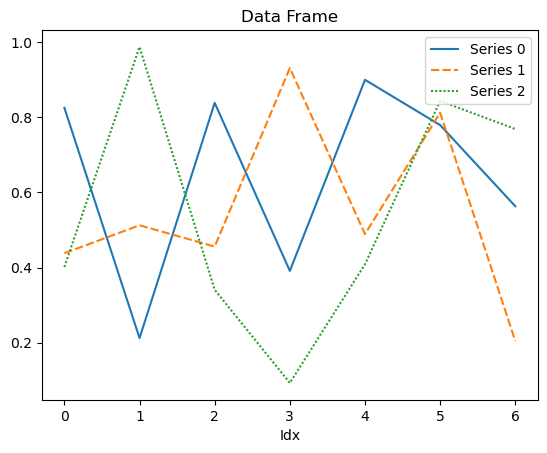

In [4]:
# plotting od dataframe
hA = sns.lineplot(dfA)
hA.set_title('Data Frame')

In [5]:
# creation of dataframe from dictionary
dict_B = {
    'Series A' : np.random.rand(numRows),
    'Series B' : np.random.rand(numRows),
    'Series C' : np.random.rand(numRows)
}
df_B = pd.DataFrame(dict_B)
df_B

,Series A,Series B,Series C
0,0.293790,0.993497,0.644861
1,0.715538,0.323945,0.598789
2,0.795298,0.937770,0.921175
3,0.010284,0.300750,0.516352
4,0.651213,0.102656,0.537018
5,0.599009,0.068138,0.124058
6,0.367157,0.510462,0.259786


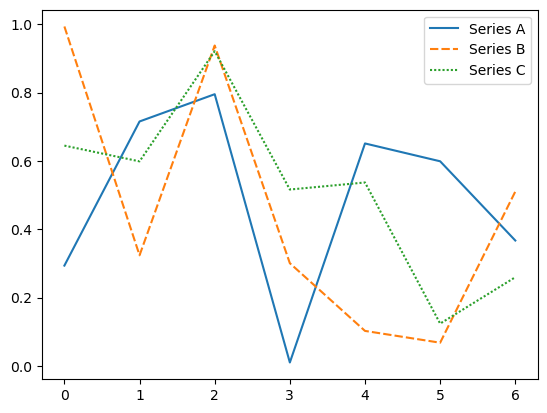

In [6]:
hA = sns.lineplot(df_B)

In [7]:
diamonds_csv_url = r'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv'
df_diamonds = pd.read_csv(diamonds_csv_url)
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [8]:
df_diamonds.dtypes

carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [9]:
df_diamonds['cut'].unique()

<ArrowStringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str

In [10]:
df_diamonds.loc[0:5, ['carat', 'price', 'clarity']]

,carat,price,clarity
0,0.23,326,SI2
1,0.21,326,SI1
2,0.23,327,VS1
3,0.29,334,VS2
4,0.31,335,SI2
5,0.24,336,VVS2


In [11]:
df_diamonds[['price','x']].min(axis=0)

price    326.0
x          0.0
dtype: float64

In [12]:
df_diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


In [13]:
group_by_cut = df_diamonds.groupby('cut')
print(f"Av price by cut: \n {group_by_cut['price'].mean()}")
print("")
print(f"Meadian price by cut: \n {group_by_cut['price'].median()}")

Av price by cut: 
 cut
Fair         4358.757764
Good         3928.864452
Ideal        3457.541970
Premium      4584.257704
Very Good    3981.759891
Name: price, dtype: float64

Meadian price by cut: 
 cut
Fair         3282.0
Good         3050.5
Ideal        1810.0
Premium      3185.0
Very Good    2648.0
Name: price, dtype: float64


<Axes: xlabel='cut', ylabel='price'>

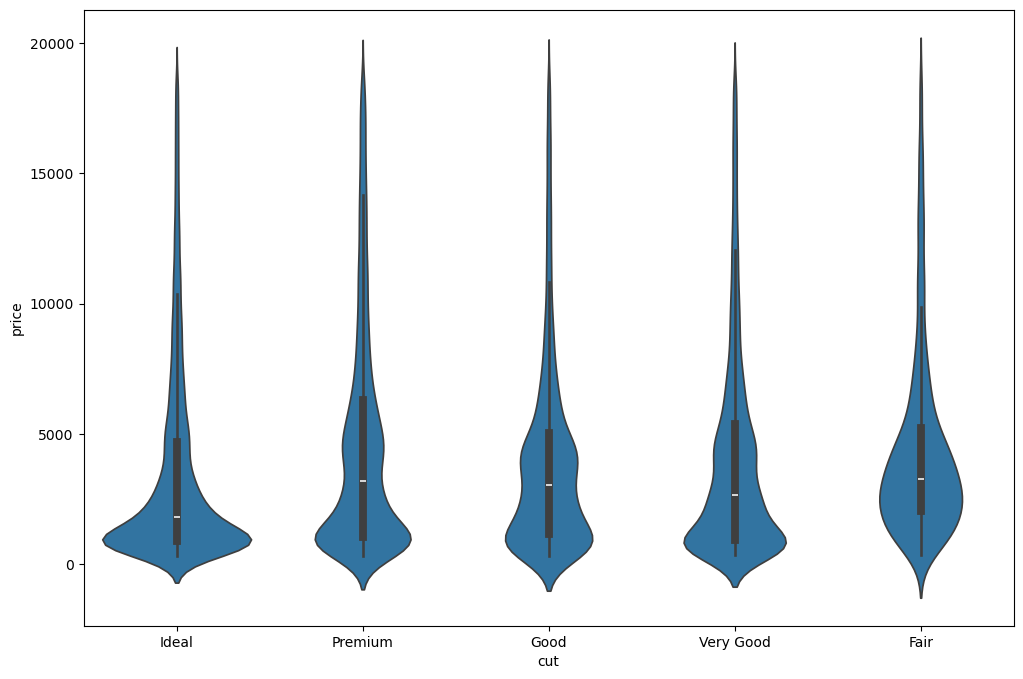

In [15]:
df_temp = df_diamonds.copy()
hf, hA = plt.subplots(figsize = (12, 8))
sns.violinplot(df_diamonds, x = 'cut', y='price')